# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Natalie Ho, Evelyn Chen

**ID**: nh424, ec877

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/hw2-natalie`


In [2]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

Shown in linked word document 

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?

We decided to use two control volumes: the first CV from the first discharge from the upstream river, and the second CV from the second discharge (15 km away the first discharge point). These two control volumes are the "junctions" of the diagram, in that they have some input and output.

$$
\boxed{\text{River Inflow}}
\;\;\longrightarrow\;\;
\boxed{\text{CV1: Discharge 1 + Deposition + Decay}}
\;\;\longrightarrow\;\;
\boxed{\text{CV2: Discharge 2 + Deposition + Decay}}
\;\;\longrightarrow\;\;
\boxed{\text{River Outflow}}
$$


#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

To model the concentration of CRUD, $C(x)$, as a function of distance downriver:
Two parameters that we are given are the $velocity$ and $k_{rate}$. We can find the first-order decay rate as $k_x$:

$$
k_x = \frac{k_t}{v} = \frac{0.36}{10} = 0.036 \;\text{km}^{-1}.
$$

As seen fomr the systems diagram, the fluctuating values are deposition and decay.
Using mass balancing, we need to account for those variations by using the following ODE model:

$$
\frac{dy}{dx} = -Decay Rate + Deposition Rate.
$$

Substituting in our relevant variables gives us:

$$
\frac{dC}{dx} = -k_x C + \frac{D}{Q},
$$

where we are given all the parameters. $C(x)$ = CRUD concentration (kg per 1000 m$^3$),  $k_x$ = decay constant per km,  $D = 54 \;\text{kg/km/day}$ = atmospheric deposition rate,  and $Q$ = river flow (m$^3$/day).

For the first CV, our equation is 

$$
\frac{dC_1}{dx} = -k_x C_1 + \frac{D}{Q},
$$
$$
C_1(0) = C_0
$$.

For the second CV (15 km downstream from the first discharge point source), our equation is 

$$
\frac{dC_2}{dx} = -k_x C + \frac{D}{Q},
$$
$$
C_2(15) = C_1(15) + \frac{Q_2}{Q}
$$.

Solving analytically, the solution to this first-order linear ODEs are

$$
C(x_1) = \left(C(0) - \frac{D}{Q k_x}\right) e^{-k_x x} + \frac{D}{Q k_x}.
$$

and 

$$
C(x_2) = \left(C_2(15) - \frac{D}{Q k_x}\right) e^{-k_x (x-15)} + \frac{D}{Q k_x}.
$$

The first term, $\left(C(0) - \tfrac{D}{Qk_x}\right)e^{-k_x x}$, represents the decay factor, while the second term, $\tfrac{D}{Qk_x}$, represents the deposition


In [3]:
# given parameters
Q0 = 250_000.0         # (m^3/day)
C0 = 0.5               # (kg/1000 m^3)

dist = 15.0            # km
v = 10.0               # km/day
k = 0.36               # 1/day
k_rate = k / v         # per km
deposition_rate = 54.0 # kg/km/day
x2 = 15.0

# crud concentration should be a function of distance downriver (x)

# first CV
function CRUD_conc1(x, Q, Cinit)
    deposition_factor = deposition_rate / Q / k_rate
    return (Cinit - deposition_factor) * exp(-k_rate * x) + deposition_factor
end

# second CV
function CRUD_conc2(x, Q, C_from1, Q2, x2)
    deposition_factor = deposition_rate / Q / k_rate
    C_addition = C_from1 + Q2 / Q
    return (C_addition - deposition_factor) * exp(-k_rate * (x - x2)) + deposition_factor
end


CRUD_conc2 (generic function with 1 method)

#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

In [4]:
C_limit = 2.3 # kg/(1000m^3)

# Discharge #1
Q1 = Q0 + 40_000
C1 = (Q0*C0 + 40_000*9) / Q1
C15 = CRUD_conc1(15, Q1, C1)

# Discharge #2
Q2 = Q1 + 60_000
C2 = (Q1*C15 + 60_000*7) / Q2
C_result = CRUD_conc2(25, Q2, C2, 60_000, x2)  # use C2, not C15

# Output 
println("Concentration after first 15 km: $C15")
println("Concentration at end (25 km): $C_result")

if C_result <= C_limit
    println("Yes, system is in compliance with limit")
else
    println("No, system is NOT in compliance with limit")
end


Concentration after first 15 km: 0.976754413871807
Concentration at end (25 km): 1.5227459057104982
Yes, system is in compliance with limit


### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

Included in the pdf attached 

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

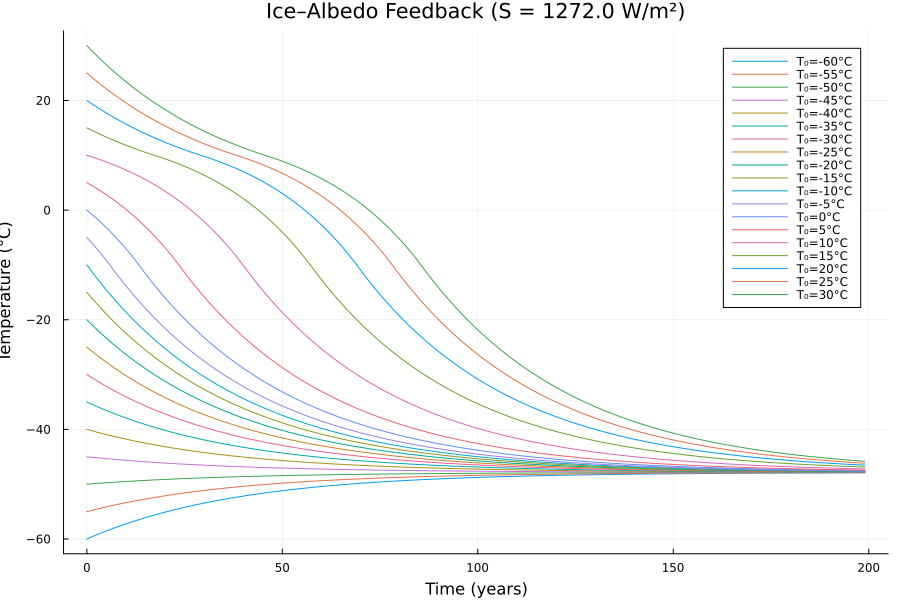

In [5]:
using Plots

# Parameters
C, A, B = 51.0, 221.2, -1.3
S       = 1272.0           # Neoproterozoic
αi, α0  = 0.5, 0.3
Δt      = 1.0
Tsteps  = 200             

# Albedo: depends on T at each step
α(T) = T <= -10  ? αi :
       T <=  10  ? αi + (α0 - αi) * ((T + 10)/20) :
                   α0

# dT/dt = [(1 - α(T)) S/4 - A + B T] / C
climate_step(T) = ((1 - α(T)) * S / 4 - A + B*T) / C

function simulate(T0; Tsteps=201, Δt=1.0)
    T = zeros(Float64, Tsteps)
    T[1] = T0
    for t in 2:Tsteps
        T[t] = T[t-1] + Δt * climate_step(T[t-1])  # forward Euler
    end
    return T
end

# plot
T0s = collect(-60.0:5.0:30.0)
ts  = 0:Δt:(Tsteps-1)
p = plot(xlabel="Time (years)", ylabel="Temperature (°C)",
         title="Ice–Albedo Feedback (S = $(S) W/m²)", size=(900,600))
for T0 in T0s
    plot!(p, ts, simulate(T0; Tsteps=Tsteps, Δt=Δt), label="T₀=$(Int(T0))°C")
end
display(p)


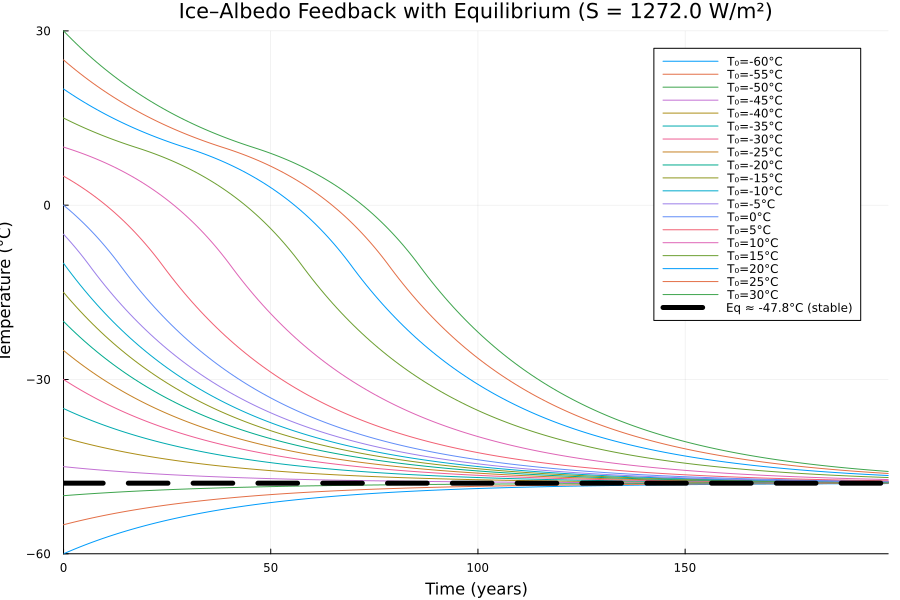

In [6]:
using Plots

# Parameters
C, A, B = 51.0, 221.2, -1.3
S       = 1272.0           # Neoproterozoic
αi, α0  = 0.5, 0.3
Δt      = 1.0
Tsteps  = 200             

# Albedo
α(T) = T <= -10  ? αi :
       T <=  10  ? αi + (α0 - αi) * ((T + 10)/20) :
                   α0

# dT/dt
climate_step(T) = ((1 - α(T)) * S / 4 - A + B*T) / C

# Forward-Euler Equation
function simulate(T0; Tsteps=201, Δt=1.0)
    T = zeros(Float64, Tsteps)
    T[1] = T0
    for t in 2:Tsteps
        T[t] = T[t-1] + Δt * climate_step(T[t-1])
    end
    return T
end

# Initial conditions and time axis
T0s = collect(-60.0:5.0:30.0)       # includes +30°C
ts  = 0:Δt:(Tsteps-1)

# --- Compute equilibria ---
k = S/4
m = (α0 - αi)/20

T_cold = (A - (1 - αi)*k) / B
den_mid = B - k*m
T_mid   = den_mid != 0 ? (A - k*(1 - αi - 10m)) / den_mid : NaN
T_warm  = (A - (1 - α0)*k) / B

valid_eqs = Tuple{Float64,String}[]
if T_cold <= -10
    push!(valid_eqs, (T_cold, "stable"))
end
if -10 <= T_mid <= 10
    push!(valid_eqs, (T_mid,  "unstable"))
end
if T_warm >= 10
    push!(valid_eqs, (T_warm, "stable"))
end

# --- Plot: trajectories + equilibrium line(s) ---
p_eq = plot(xlabel="Time (years)", ylabel="Temperature (°C)",
            title="Ice–Albedo Feedback with Equilibrium (S = $(S) W/m²)",
            size=(900,600),
            legend=:topright,
            ylims=(-60, 30),
            xlims=(first(ts), last(ts)))

for T0 in T0s
    plot!(p_eq, ts, simulate(T0; Tsteps=Tsteps, Δt=Δt), label="T₀=$(Int(T0))°C")
end

# Overlay equilibrium lines in bold black
for (Teq, stab) in valid_eqs
    if stab == "stable"
        hline!(p_eq, [Teq], label="Eq ≈ $(round(Teq, digits=1))°C (stable)",
               linestyle=:dash, linewidth=5, color=:black)
    else
        hline!(p_eq, [Teq], label="Eq ≈ $(round(Teq, digits=1))°C (unstable)",
               linestyle=:dashdot, linewidth=5, color=:red)
    end
end

display(p_eq)


The codes above show the **ice–albedo feedback climate model** using a forward Euler method.  
We are using the given Neoproterozoic solar constant $S = 1272 \ \mathrm{W\,m^{-2}}$ and run trajectories for initial temperatures spanning $T_0 = -60^\circ \mathrm{C}$ to $+30^\circ \mathrm{C}$.

- **Albedo function**:  
  $\alpha(T)$ is defined piecewise:
  - $\alpha = \alpha_i = 0.5$ for $T \leq -10^\circ\mathrm{C}$  
  - $\alpha = \alpha_0 = 0.3$ for $T \geq 10^\circ\mathrm{C}$  

- **Dynamics**:  
  The temperature equation is: 
  $$
  \frac{dT}{dt} = \frac{(1-\alpha(T))S}{4} - A + B T \quad \Big/ \ C,
  $$
  where $A=221.2$, $B=-1.3$, and $C=51.0$.

- **Simulation**:  
  Each trajectory is integrated for 200 years with a time step of 1 year. The first plot shows the evolution of $T(t)$ for all initial conditions.

- **Equilibrium calculation**:  
  Analytical solutions for $F(T)=0$ are computed separately in each region (cold, intermediate, warm).  
  The slope is given by
  $$
  \frac{dF}{dT} =
  \begin{cases}
  B = -1.3 & (T \leq -10), \\[6pt]
  B - \tfrac{S}{4}\,m = -1.3 - 318(-0.01) = +1.88 & (-10 < T < 10), \\[6pt]
  B = -1.3 & (T \geq 10),
  \end{cases}
  $$
  where $m = \tfrac{\alpha_0-\alpha_i}{20} = -0.01$.  
  - Negative slope $\,(dF/dT<0)\,$ ⇒ **stable equilibrium**  
  - Positive slope $\,(dF/dT>0)\,$ ⇒ **unstable equilibrium**

- **Plots**:  
  1. The first figure displays trajectories only, showing that all initial conditions collapse toward the same equilibrium.  
  2. The second figure overlays the equilibrium temperature(s) with dashed lines.  
     For $S=1272$, there is a single valid cold equilibrium at
  $$
  T^* \approx -47.9^\circ \mathrm{C}, \quad \frac{dF}{dT} = -1.3 < 0 \;\;\Rightarrow\;\; \text{stable}.
  $$

**Conclusion:**  
Regardless of the starting temperature (even as high as $30^\circ\mathrm{C}$), the system converges to the cold equilibrium. The negative slope confirms its stability, demonstrating that the Snowball Earth state under Neoproterozoic is solar forcing.


#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

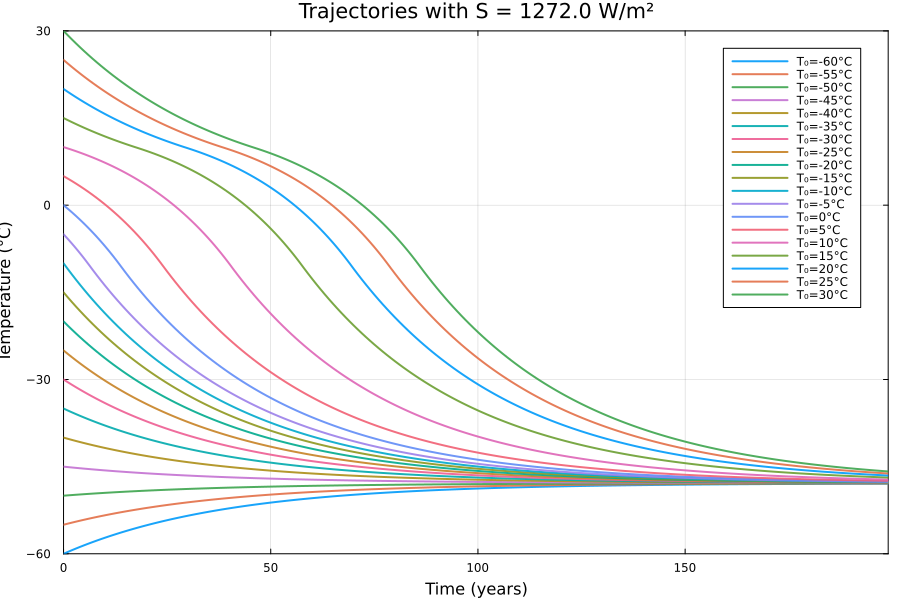

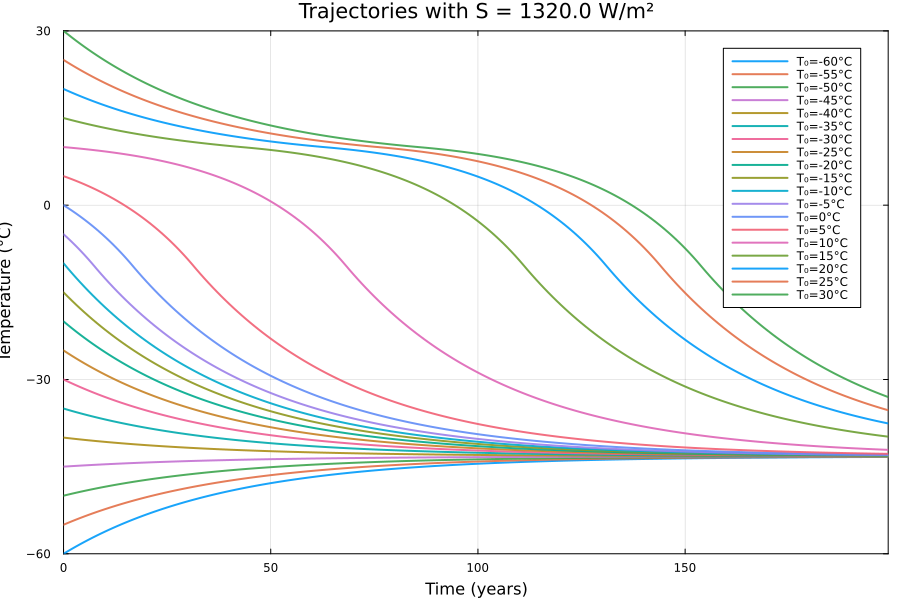

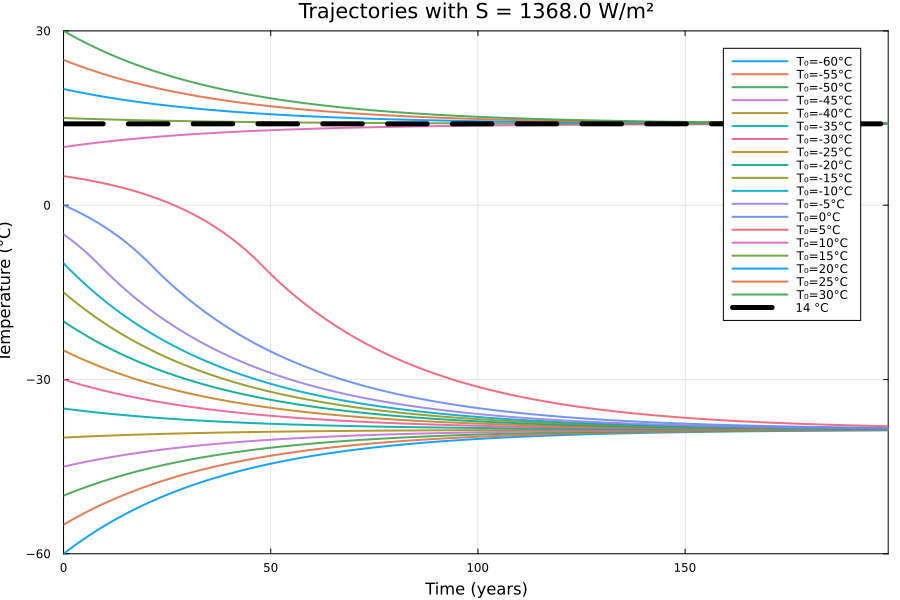

In [7]:
using Plots

# Parameters
C, A, B = 51.0, 221.2, -1.3
αi, α0  = 0.5, 0.3
Δt, Tsteps = 1.0, 200

# Albedo
α(T) = T <= -10  ? αi :
       T <=  10  ? αi + (α0 - αi) * ((T + 10)/20) :
                   α0

# dT/dt for any S
climate_step(T, S) = ((1 - α(T)) * S / 4 - A + B*T) / C

# Forward Euler 
function simulate(T0, S; Tsteps=201, Δt=1.0)
    T = zeros(Float64, Tsteps)
    T[1] = T0
    for t in 2:Tsteps
        T[t] = T[t-1] + Δt * climate_step(T[t-1], S)
    end
    return T
end

# Inital Conditions & time axis
T0s = collect(-60.0:5.0:30.0)
ts  = 0:Δt:(Tsteps-1)

# Reusable plotting helper
function plot_for_S(S; show14::Bool=false)
    p = plot(xlabel="Time (years)", ylabel="Temperature (°C)",
             title="Trajectories with S = $(S) W/m²",
             size=(900,600), legend=:topright, framestyle=:box,
             ylims=(-60,30), xlims=(first(ts), last(ts)))
    for T0 in T0s
        plot!(p, ts, simulate(T0, S; Tsteps=Tsteps, Δt=Δt),
              label="T₀=$(Int(T0))°C", linewidth=2, alpha=0.9)
    end
    if show14
        hline!(p, [14.0], label="14 °C", linestyle=:dash, linewidth=5, color=:black)
    end
    return p
end

# Changing S Values 
S_low  = 1272.0                 # Neoproterozoic
S_mid  = 1320.0                 # moderately higher
S_high = 4*(A - B*14)/(1 - α0)  # S that gives warm T* = 14°C (≈ 1368)

# Make Plots 
p1 = plot_for_S(S_low;  show14=false)   # Neoproterozoic
p2 = plot_for_S(S_mid;  show14=false)   # Increased S
p3 = plot_for_S(S_high; show14=true)    # Higher S with bold 14°C line

display(p1)
display(p2)
display(p3)


## 3.3 Problem Summary

- **At $S=1272\ \mathrm{W\,m^{-2}}$:**  
  All trajectories, regardless of initial temperature, converge to the same cold equilibrium near $-48^\circ \mathrm{C}$. This reproduces the Snowball Earth state from Problem 3.2.  

- **At $S=1320\ \mathrm{W\,m^{-2}}$:**  
  The system still collapses into the Snowball state. No warm equilibrium is visible yet, and trajectories starting warm eventually freeze.  

- **At $S=1368\ \mathrm{W\,m^{-2}}$:**  
  Two different outcomes appear. Cold initial conditions still fall to the frozen equilibrium, but warm initial conditions rise and stabilize near $14^\circ \mathrm{C}$. This shows the model becomes **bistable**: both a cold and a warm state are stable, depending on the initial condition.  

**Summary:** To answer this question, we decided to plot three graphs building upon what we did in 3.2. We started with the Neoproterozoic value of S and then knew that the last graph we wanted to make was present day value of S. After running more iterations of the values in between these two values, we found that this value plotted showed what the trends are showing as we increase S and how the temperature changes. The plots demonstrate that increasing $S$ creates the possibility of a warm $14^\circ \mathrm{C}$ equilibrium, but the Snowball state remains stable at the same time. Simply raising $S$ is not enough by itself to deglaciate Earth from a frozen start.  


## References
LaTex Cheatsheet was consulted for LaTex commands. Solutions to the first-order linear ODE were also double-checked after they were worked out by consulting online calculators.
Thank you to TA Samantha Davies for her guidance in reviewing Problem 2.2 and clarifying Problem 2.3. Specifically, that the task is not to use 14 °C as a fixed value, but rather to vary the values of 𝑆 and compare them against 𝑇. Thank you!